# **Business Context**

A sales forecast predicts future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits, which include improved decision-making about the future and the reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establishes benchmarks that can be used to assess trends in the future.

# **Objective**

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm, not just to build a predictive model based on historical sales data but also to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

# **Data Dictionary**

The data contains the different attributes of the various products and stores.

- **Product_Id**: Unique identifier of each product, each identifier having two letters at the beginning, followed by a number
- **Product_Weight**: Weight of each product
- **Product_Sugar_Content**: Sugar content of each product, like low sugar, regular, and no sugar
- **Product_Allocated_Area**: Ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type**: Broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP**: Maximum retail price of each product
- **Store_Id**: Unique identifier of each store
- **Store_Establishment_Year**: Year in which the store was established
- **Store_Size**: Size of the store, depending on sq. feet, like high, medium, and low
- **Store_Location_City_Type**: Type of city in which the store is located, like Tier 1, Tier 2, and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than that of its Tier 2 and Tier 3 counterparts
- **Store_Type**: Type of store depending on the products that are being sold there, like Departmental Store, Supermarket Type 1, Supermarket Type 2, and Food Mart
- **Product_Store_Sales_Total**: Total revenue generated by the sale of that particular product in that particular store

# **Installing and Importing Necessary Libraries**

In [ ]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==1.3.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 533.1/533.1 kB 16.8 MB/s eta 0:00:00


In [ ]:
# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd
import sklearn

# Data splitting
from sklearn.model_selection import train_test_split, GridSearchCV

# Data preprocessing and pipeline creation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline, make_pipeline

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ensemble and tree-based regressors
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Model serialization
import joblib

# File and OS operations
import os
import shutil

# API requests
import requests

# Hugging Face Hub authentication
from huggingface_hub import login, HfApi

# Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
# Set scikit-learn's display mode to 'diagram' for better visualization of pipelines and estimators
sklearn.set_config(display='diagram')

# **Data Loading and Overview**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

#Load the dataset
SuperKart_data = pd.read_csv ('/content/drive/MyDrive/Python/SuperKart.csv')

Mounted at /content/drive


In [ ]:
# Create a copy of the dataframe
df = SuperKart_data.copy()

In [ ]:
# Display the first five rows of the dataset
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [ ]:
# Display the number of rows and columns in the dataset
df.shape

(8763, 12)

**Observation -** The dataset has 8763 rows and 12 columns

In [ ]:
# Display the column names of the dataset
df.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


**Observations-**

*   The dataset contains 8,763 records and 12 features
*   There are no missing values in the dataset, as all columns contain 8,763 non-null observations.
*   The dataset consists of 5 numerical features and 7 categorical/object features
*   The target variable Product_Store_Sales_Total is continuous,thus, its a regression problem



# **Exploratory Data Analysis**

Let's start by defining the target and predictor (numerical and categorical) variables.

In [ ]:
# Define the target variable for the regression task
target = 'Product_Store_Sales_Total'

# Let's define the numeric and categorical features
numeric_features = df.select_dtypes(include=np.number).columns
categorical_features = df.select_dtypes(exclude=np.number).columns
print(f"Numerical features: {list(numeric_features)}")
print(f"Categorical features: {list(categorical_features)}")

Numerical features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical features: ['Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


In [ ]:
# Generate summary statistics for numerical features
df[numeric_features].describe()

,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,8763.000000,8763.000000,8763.000000,8763.000000,8763.000000
mean,12.653792,0.068786,147.032539,2002.032751,3464.003640
std,2.217320,0.048204,30.694110,8.388381,1065.630494
min,4.000000,0.004000,31.000000,1987.000000,33.000000
25%,11.150000,0.031000,126.160000,1998.000000,2761.715000
50%,12.660000,0.056000,146.740000,2009.000000,3452.340000
75%,14.180000,0.096000,167.585000,2009.000000,4145.165000
max,22.000000,0.298000,266.000000,2009.000000,8000.000000


**Observations-**

*   The dataset shows good variation in product pricing, allocated display area, and sales values
*   Average product-store sales are around 3464, with sales ranging from 33 to 8000
*   Most stores were established around 2009, suggesting a larger proportion of newer stores in the dataset.
*   Product_MRP and Product_Allocated_Area exhibit a wide spread, indicating their potential influence on sales performance.





In [ ]:
# Compute the proportion of each class in the target variable
df[target].value_counts(normalize=True)

,proportion
Product_Store_Sales_Total,
3511.58,0.000342
2927.84,0.000228
5012.40,0.000228
4020.89,0.000228
3890.89,0.000228
...,...
2393.83,0.000114
3440.90,0.000114
2892.64,0.000114


**Observations-**

*   The target variable Product_Store_Sales_Total appears to have a highly diverse distribution with many unique sales values.
*   Most sales values contribute a very small proportion individually, indicating that sales are continuously distributed rather than concentrated around a few values.



# **Univariate Analysis**

**Univariate Analysis on all Numerical Features -**

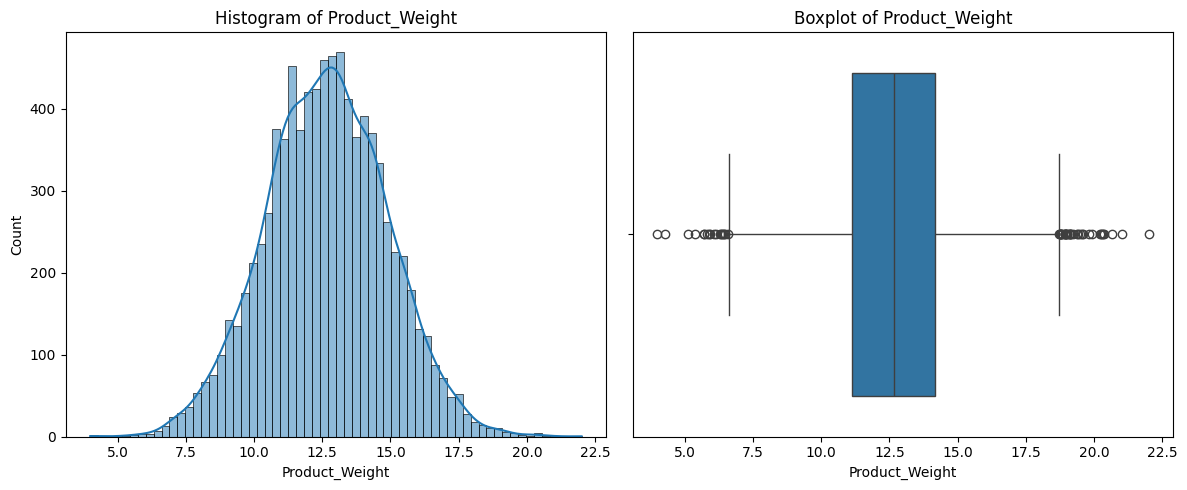

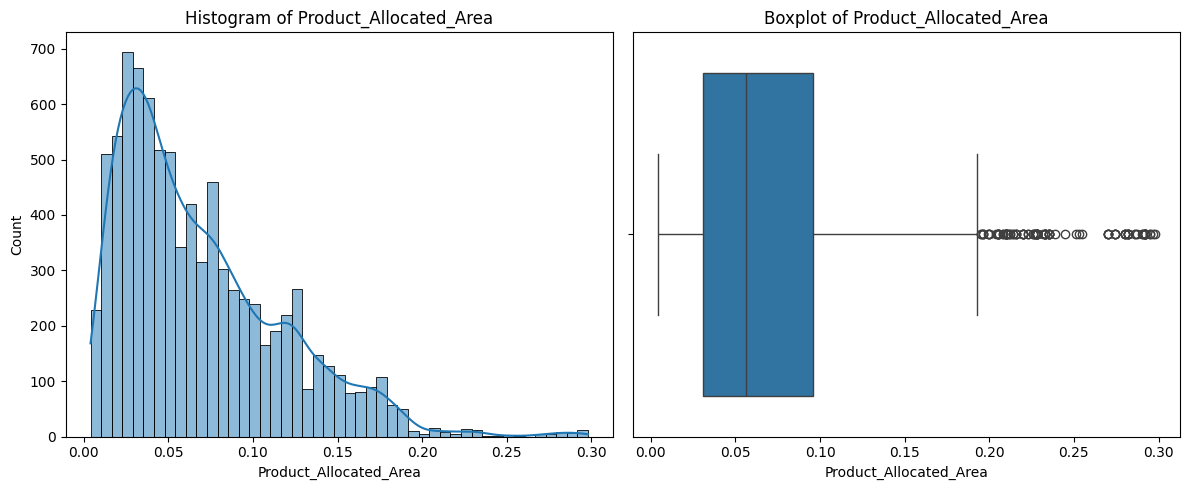

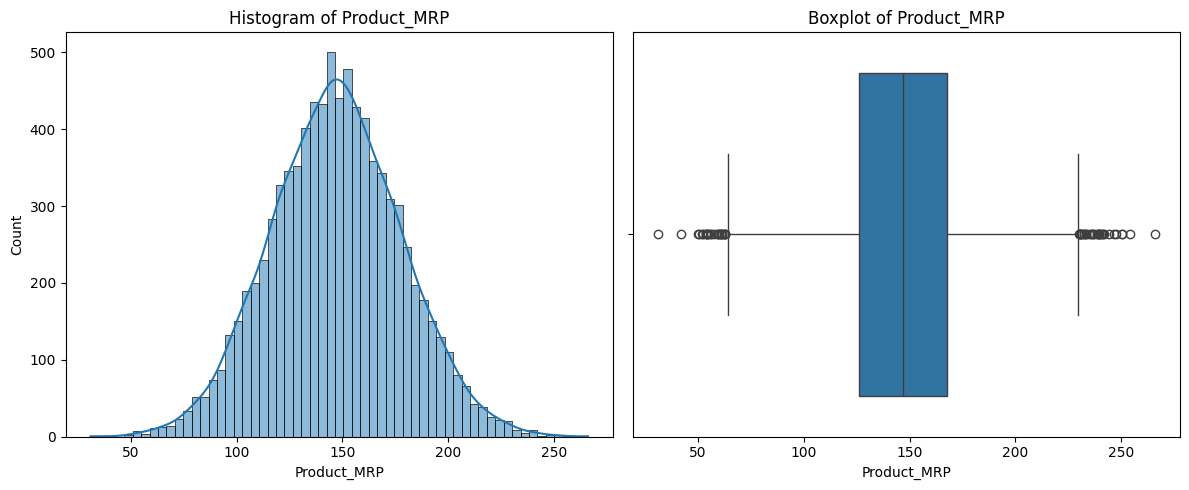

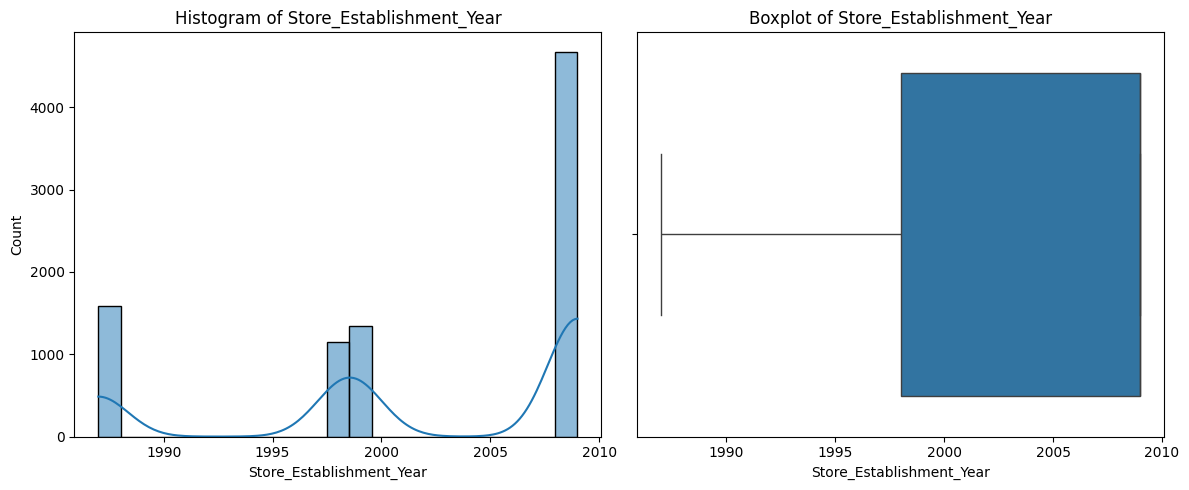

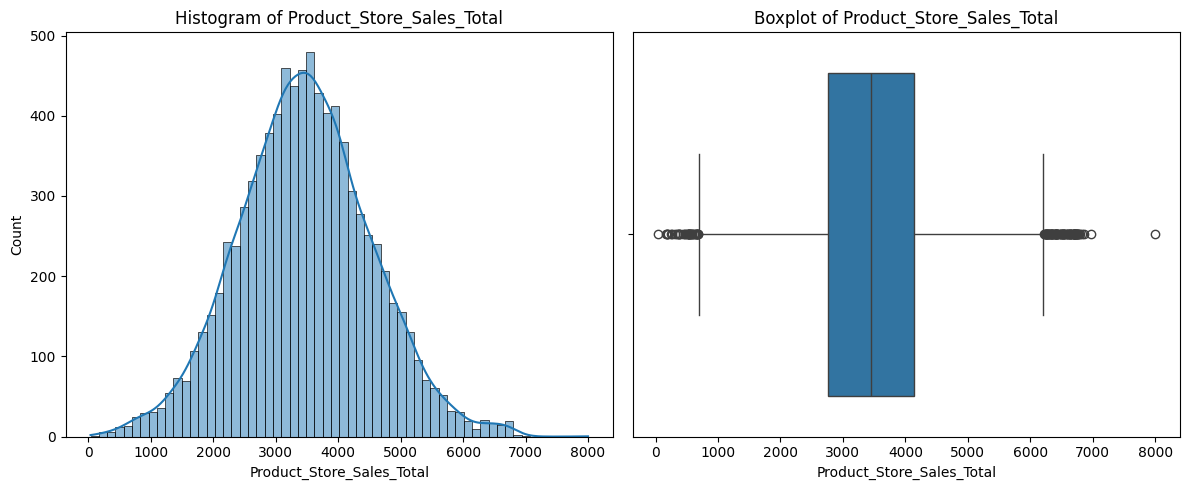

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
numeric_features = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Establishment_Year',
    'Product_Store_Sales_Total'
]

# Univariate analysis
for col in numeric_features:

    plt.figure(figsize=(12,5))

    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

**Observations-**

1.   **Product_Weight**-

*   The distribution of Product_Weight appears approximately normal and centered thus overall the feature is fairly well distributed.
*   Since the distribution is close to normal, major transformation may not be required.

2.   **Product_Allocated_Area**-

*   Product_Allocated_Area is positively skewed, with most products occupying smaller display areas.
*   Several upper-end outliers are observed.

3.   **Product_MRP**-

*   Product_MRP follows an approximately normal distribution centered around 140–160.
*   A few outliers are present at both lower and higher price ranges, but the overall distribution is fairly balanced.

4.   **Store_Establishment_Year**-

*   Most stores were established around 2009, The distribution is not normal and shows distinct peaks for certain years.
*   No major outliers are observed.

5.   **Product_Store_Sales_Total**-

*   The target variable follows an approximately normal distribution centered around 3000–4000 sales units.
*   A few outliers are present on both lower and higher ends, suggesting some products/stores perform exceptionally poorly or well.





**Univariate Analysis on all Categorical Features -**

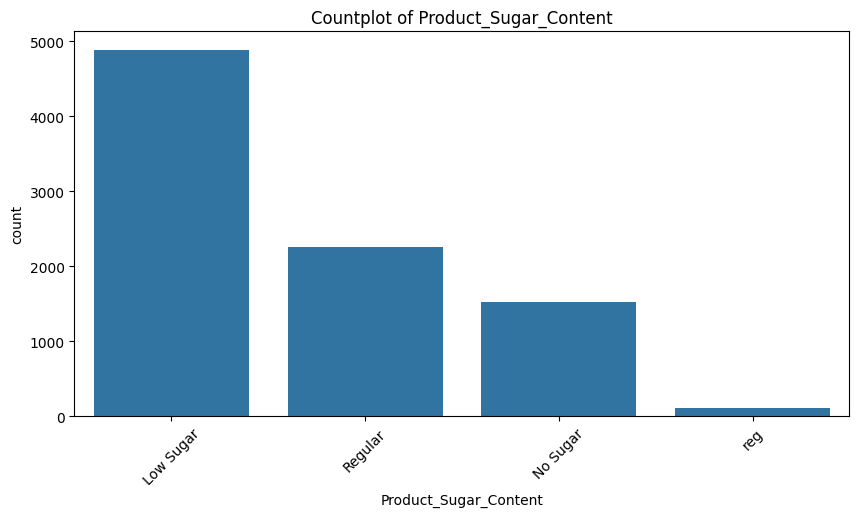

Product_Sugar_Content
Low Sugar    4885
Regular      2251
No Sugar     1519
reg           108
Name: count, dtype: int64
--------------------------------------------------


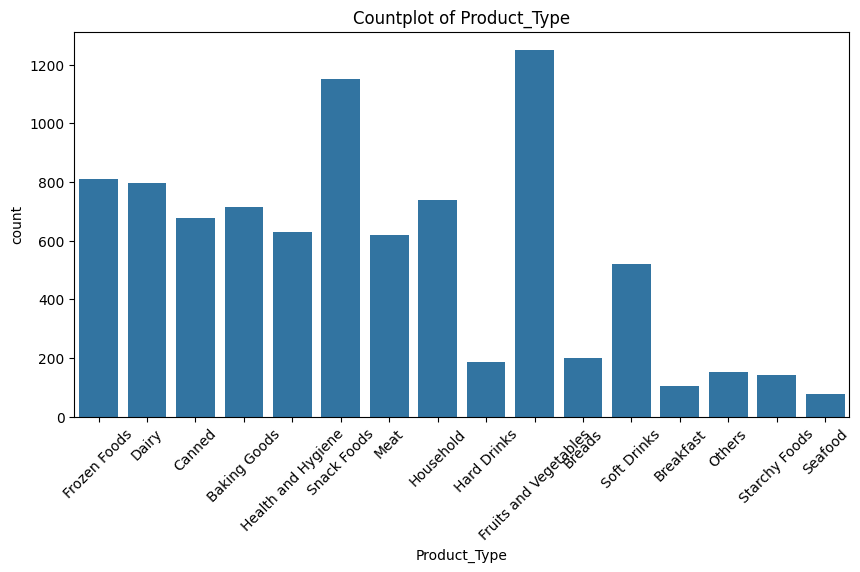

Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64
--------------------------------------------------


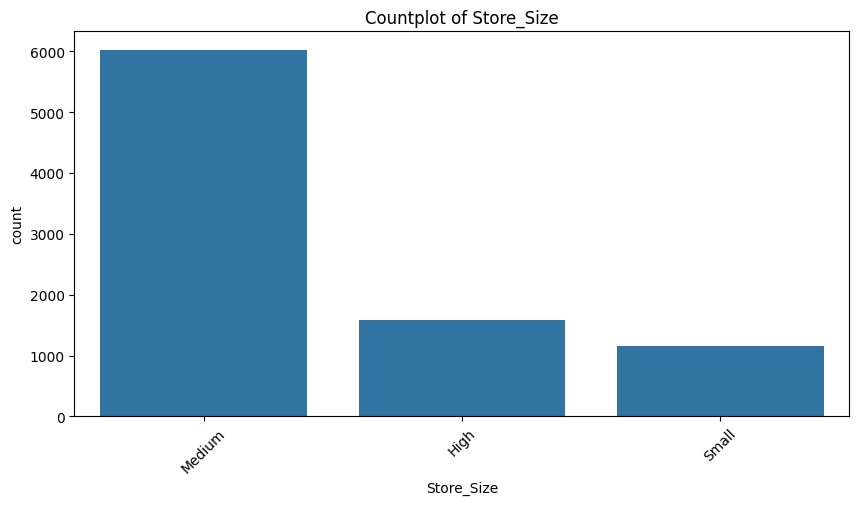

Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64
--------------------------------------------------


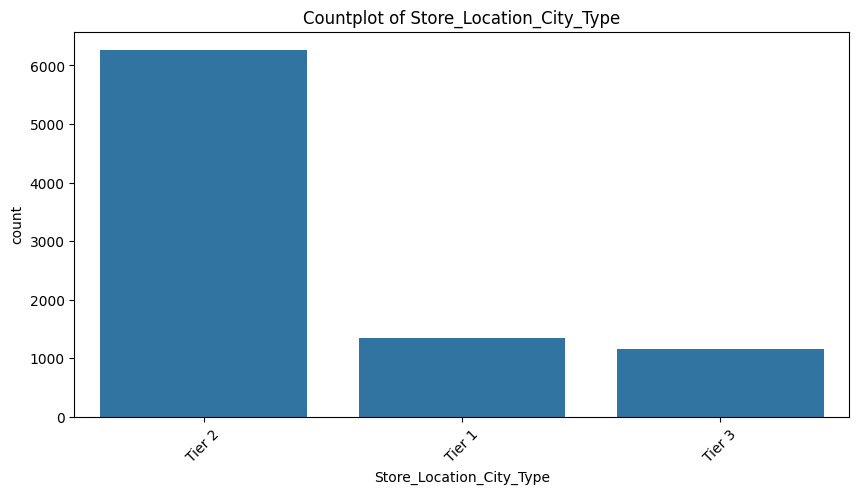

Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64
--------------------------------------------------


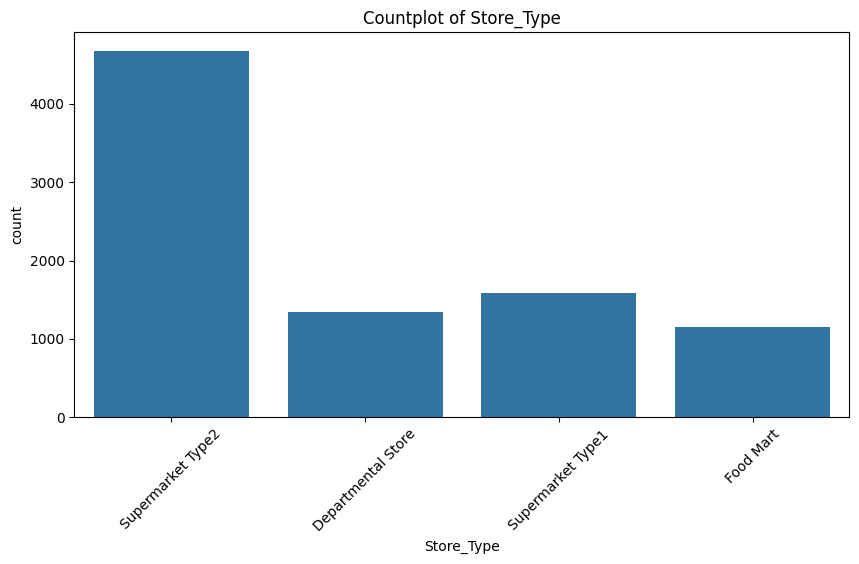

Store_Type
Supermarket Type2     4676
Supermarket Type1     1586
Departmental Store    1349
Food Mart             1152
Name: count, dtype: int64
--------------------------------------------------


In [ ]:
categorical_features = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

for col in categorical_features:

    plt.figure(figsize=(10,5))

    sns.countplot(data=df, x=col)

    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)

    plt.show()

    print(df[col].value_counts())
    print("-"*50)

**Observations-**


1.  **Product_Sugar_Content** -


*   The product catalog is heavily skewed toward low-sugar items
*   reg” (108) is clearly a Likely a typo or inconsistent encoding of “Regular”

2.   **Product_Type** -
*   The dataset is concentrated in a few key categories like Fruits and Vegetables and Snack Foods, while most other product types have moderate to low representation.
*   Overall, it shows a long-tail distribution with many low-frequency categories, which may require consolidation or careful encoding for modeling.

3.   **Product_Type** -
*   The dataset is concentrated in a few key categories like Fruits and Vegetables and Snack Foods, while most other product types have moderate to low representation.
*   Overall, it shows a long-tail distribution with many low-frequency categories, which may require consolidation or careful encoding for modeling.

4.   **Store_Size** -
*   The dataset is dominated by Medium-sized stores (6025), indicating most sales transactions come from medium-scale retail outlets.
*   High (1586) and Small (1152) stores are significantly less represented, showing an imbalance in store size distribution.

5.   **Store_Location_City_Type** -
*   The dataset is largely concentrated in Tier 2 cities (6262), followed by a much smaller share from Tier 1 (1349) and Tier 3 (1152) cities.
*   Overall, it indicates a strong skew toward Tier 2 locations

6.   **Store_Type** -
*   The dataset is predominantly composed of Supermarket Type2 stores (4676), while Supermarket Type1, Departmental Stores, and Food Mart have comparatively lower representation.




# **Bivariate Analysis**

**Numerical Features ↔ Target Variable**

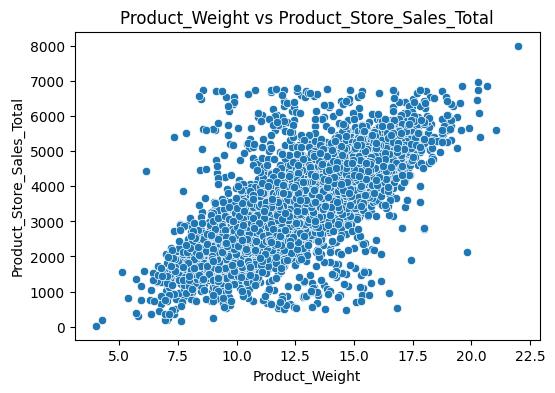

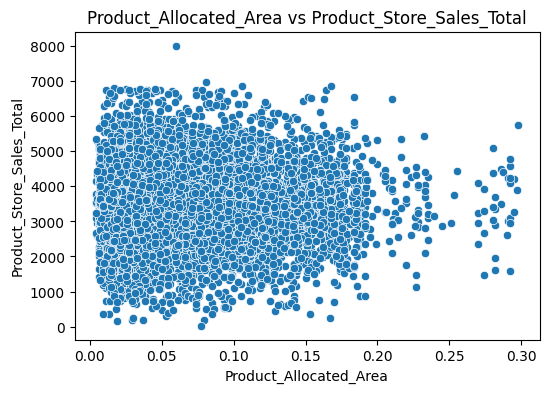

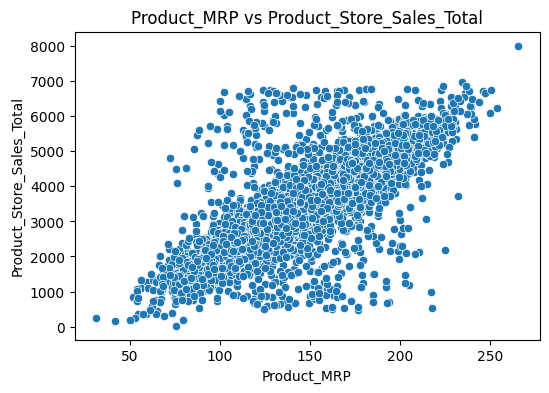

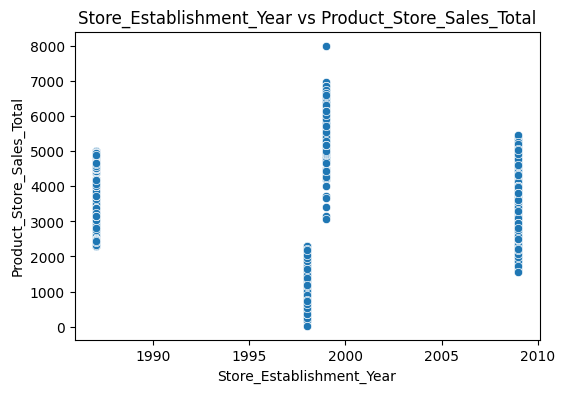

In [ ]:
# Scatterplot
target = 'Product_Store_Sales_Total'

numeric_features = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Establishment_Year'
]

for col in numeric_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x=col,
        y=target
    )

    plt.title(f'{col} vs {target}')

    plt.show()

**Observations-**

*   Product_Weight vs Product_Store_Sales_Total: There is a clear positive relationship — as product weight increases, total store sales also tend to increase. Most products with weights between 10–18 show higher sales concentrations around 3000–6000.
*   Product_Allocated_Area vs Product_Store_Sales_Total: The relationship appears weak or scattered. Sales values are spread across almost all allocated area values, indicating that allocated area alone may not strongly influence sales.
*   Product_MRP vs Product_Store_Sales_Total: There is a strong positive correlation between MRP and total sales. Products with higher MRP values generally achieve higher store sales, showing a clear upward trend.
*   Store_Establishment_Year vs Product_Store_Sales_Total: Sales vary noticeably across establishment years. Stores established around 1999 tend to record the highest sales values, while stores from 1998 show comparatively lower sales.

**Correlation Matrix**

In [ ]:
for col in numeric_features:

    corr = df[col].corr(df[target])

    print(f'Correlation between {col} and Sales: {corr}')

Correlation between Product_Weight and Sales: 0.737954999603134
Correlation between Product_Allocated_Area and Sales: -0.0009327969431145549
Correlation between Product_MRP and Sales: 0.7879889168895267
Correlation between Store_Establishment_Year and Sales: -0.18502657657628024


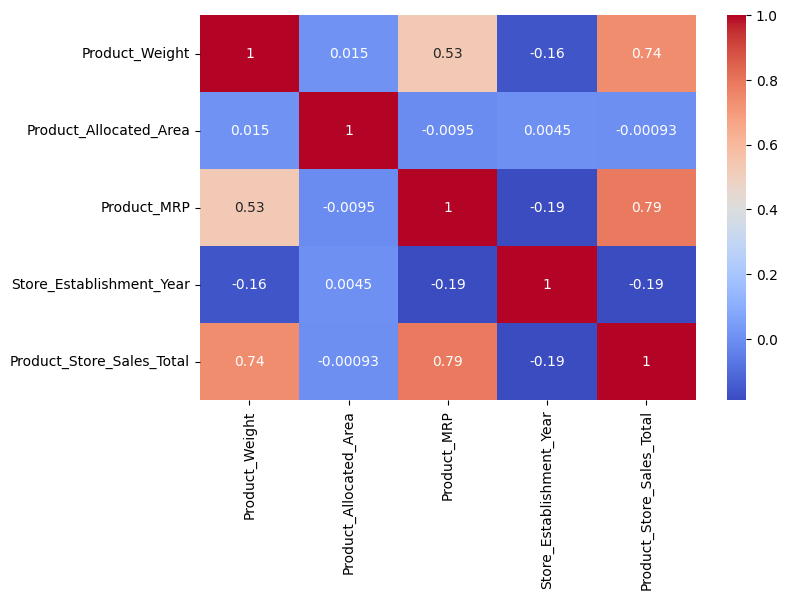

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df[numeric_features + [target]].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

**Observations-**
*   Product_MRP (0.788) and Product_Weight (0.738) show a strong positive correlation with sales, indicating that higher-priced and heavier products tend to generate higher sales values.
*   Store_Establishment_Year (-0.185) has a weak negative correlation with sales, suggesting older stores may have slightly lower sales performance.
*   Product_Allocated_Area (-0.001) shows almost no correlation with sales, indicating shelf allocation area has minimal direct linear relationship with sales in this dataset.


**Categorical Features ↔ Target Variable**

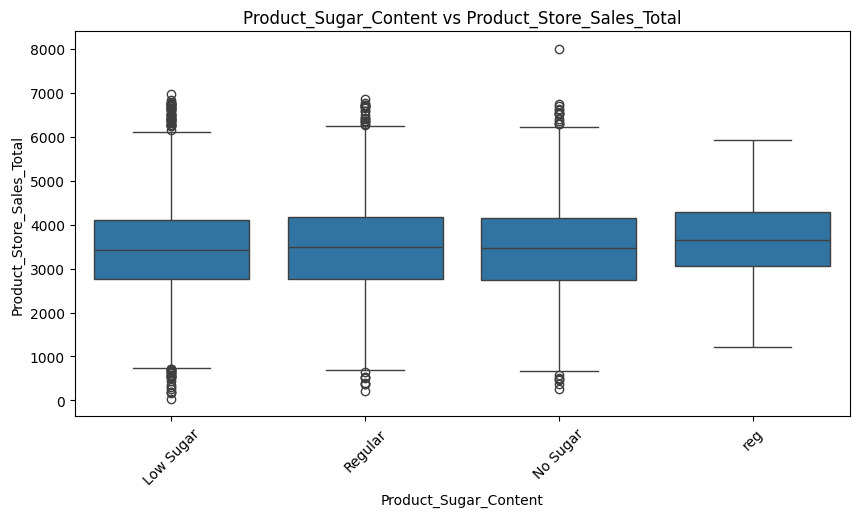

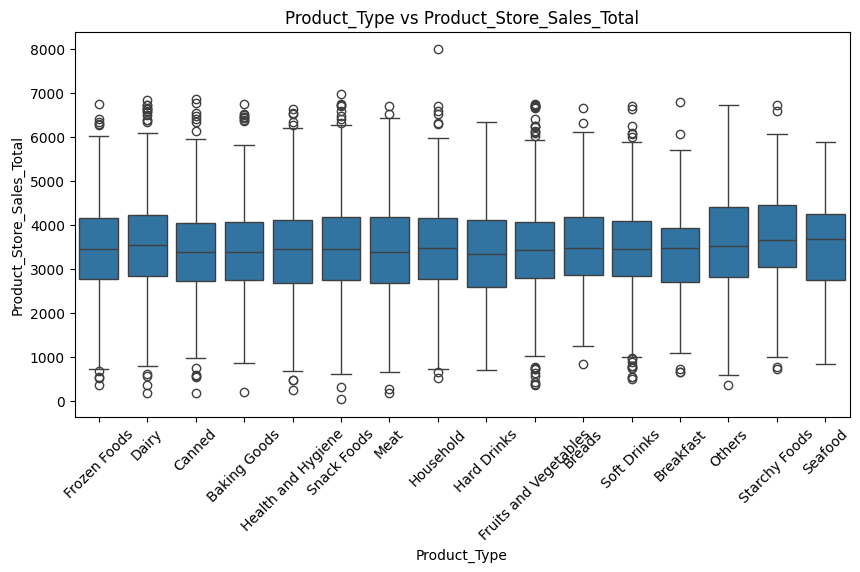

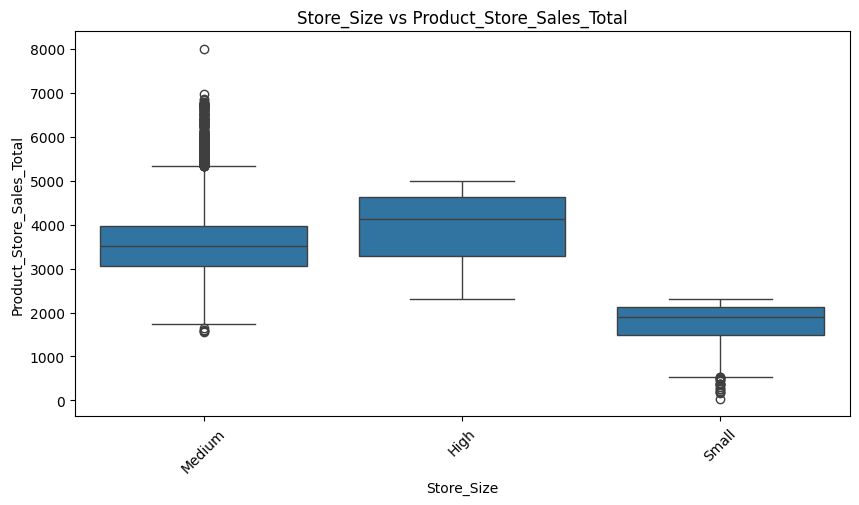

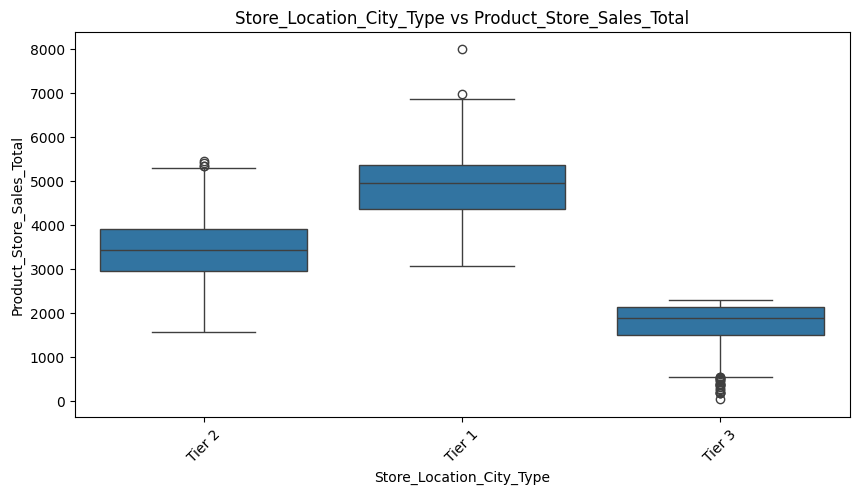

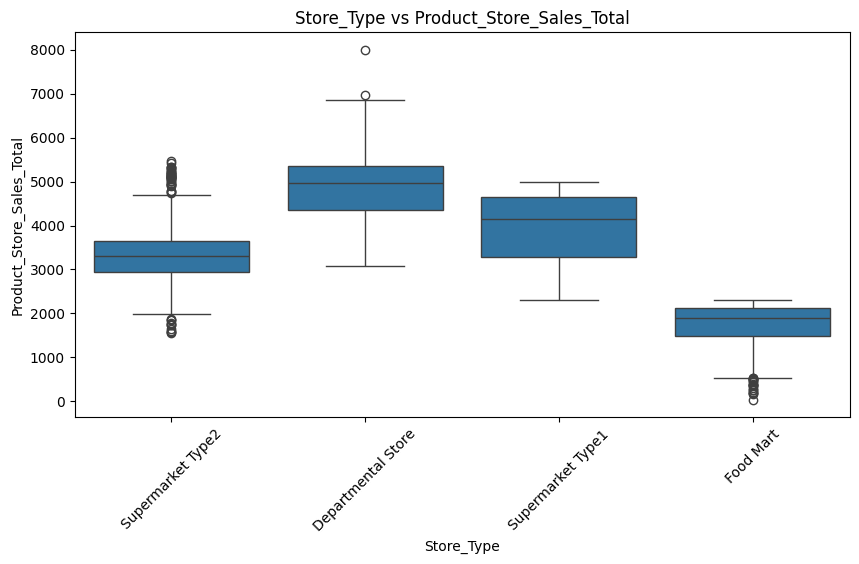

In [ ]:
#Boxplot

categorical_features = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type'
]

for col in categorical_features:

    plt.figure(figsize=(10,5))

    sns.boxplot(
        data=df,
        x=col,
        y=target
    )

    plt.xticks(rotation=45)

    plt.title(f'{col} vs {target}')

    plt.show()

**Observations-**

*   Product_Sugar_Content vs Product_Store_Sales_Total: Sales distributions across sugar content categories are fairly similar, with median sales values lying close to each other. The category labeled “reg” shows a slightly higher median sales trend compared to the others.
*   Product_Type vs Product_Store_Sales_Total: Sales vary moderately across product types.Some product types exhibit higher variability and more extreme outliers than others.
*   Store Size Impact: Large stores consistently achieve the highest product sales, followed by medium stores, while small stores show the lowest sales performance with several low-value outliers.
*   City Tier Impact: Stores located in Tier 1 cities generate the highest sales overall, Tier 2 cities show moderate sales, and Tier 3 cities have the lowest sales distribution with noticeable low-sales outliers.
*   Store Type Performance: Supermarket Type1 stores achieve the highest overall sales, followed by Supermarket Type2, whereas Food Mart stores record the lowest sales performance with many lower-end outliers.



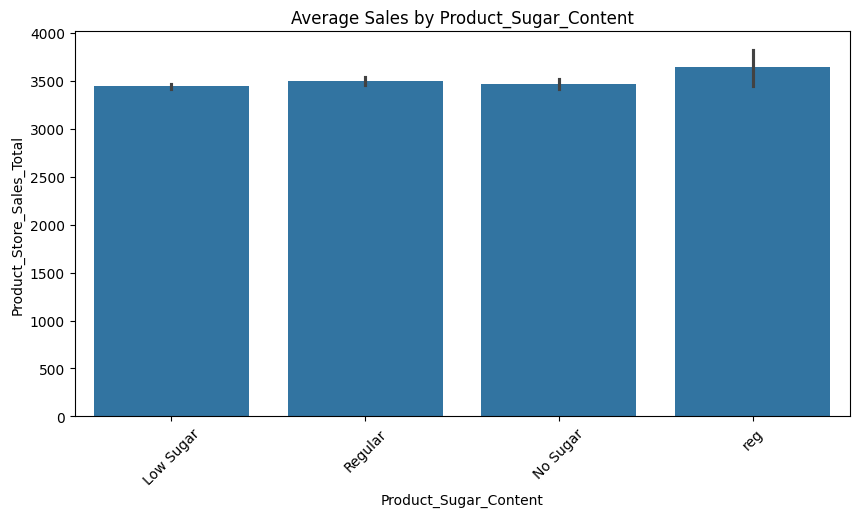

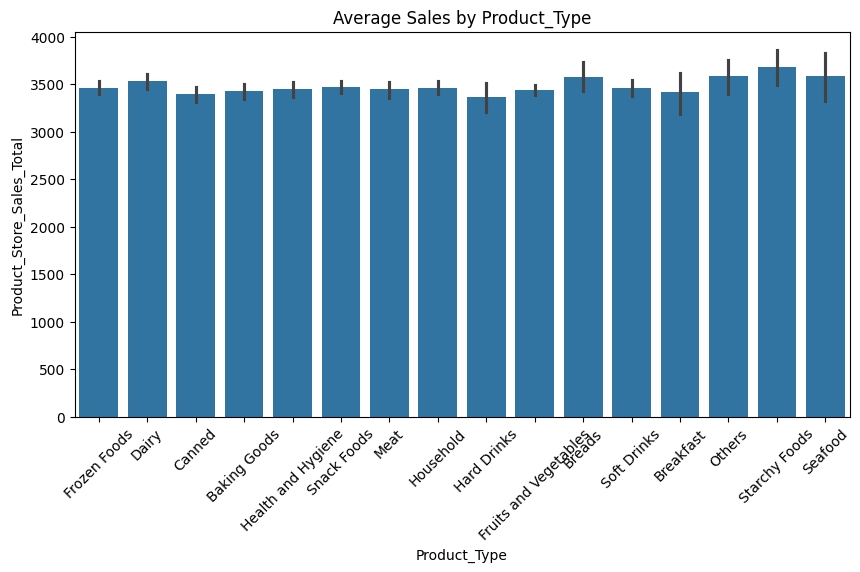

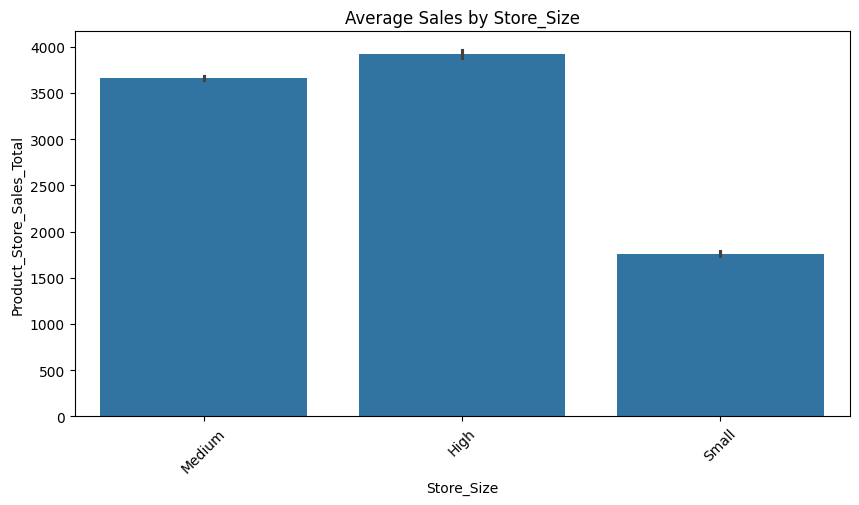

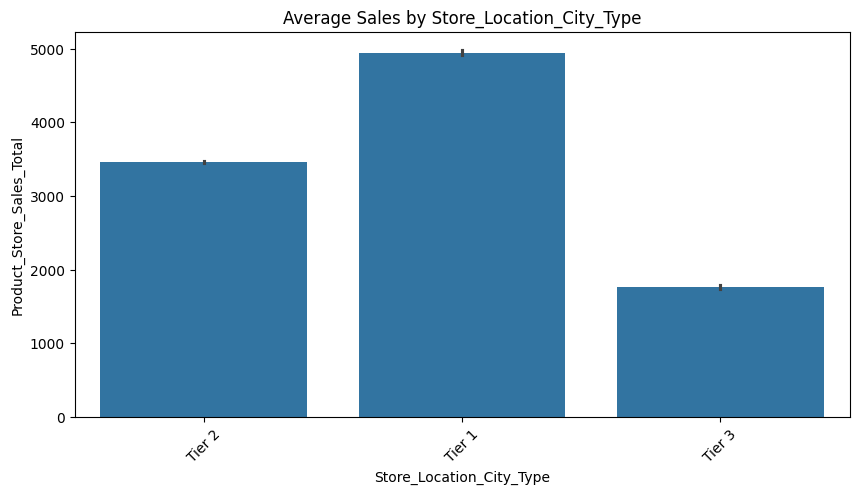

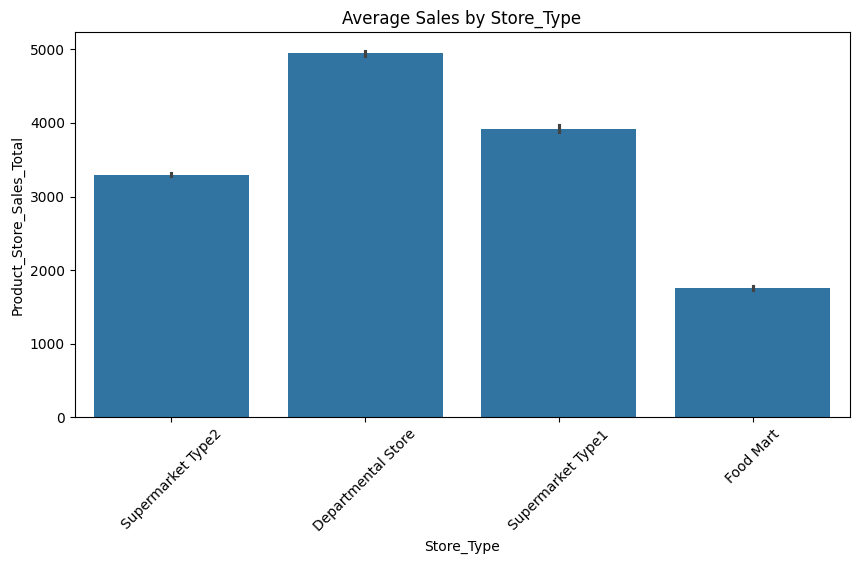

In [ ]:
#Barplot
for col in categorical_features:

    plt.figure(figsize=(10,5))

    sns.barplot(
        data=df,
        x=col,
        y=target
    )

    plt.xticks(rotation=45)

    plt.title(f'Average Sales by {col}')

    plt.show()

# **Data Preprocessing**

**Missing Value Treatment**

In [ ]:
df.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


**Outlier Detection & Treatment**

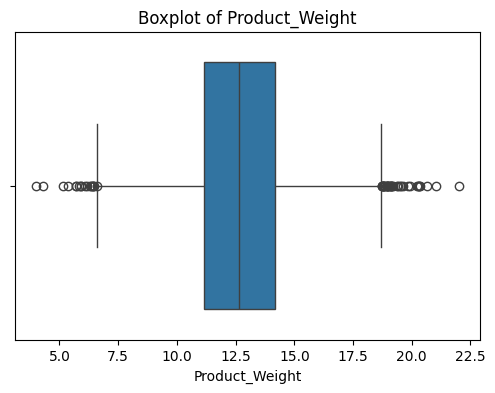

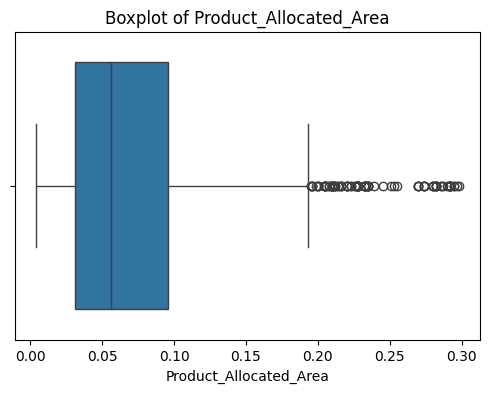

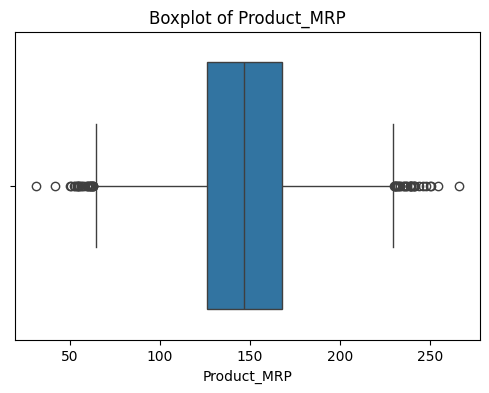

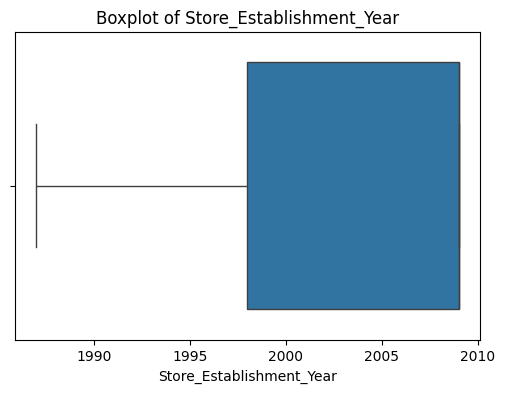

In [ ]:
#Outlier Detection using Boxplots
for col in numeric_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

In [ ]:
#Detect Outliers Using IQR Method
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = ((df[numeric_features] < lower_bound) | (df[numeric_features] > upper_bound)).any(axis=1)
print(f"Number of outliers: {outliers.sum()}")

Number of outliers: 211


In [ ]:
# Treat outliers using IQR capping

for col in numeric_features:

    # Calculate Q1 and Q3
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap the outliers
    df[col] = np.where(
        df[col] < lower_bound,
        lower_bound,
        np.where(
            df[col] > upper_bound,
            upper_bound,
            df[col]
        )
    )

In [ ]:
# Recheck Outliers

Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (
    (df[numeric_features] < lower_bound) |
    (df[numeric_features] > upper_bound)
).any(axis=1)

print(f"Number of outliers after treatment: {outliers.sum()}")

Number of outliers after treatment: 0


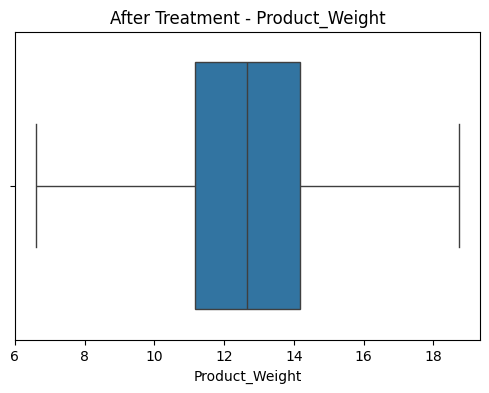

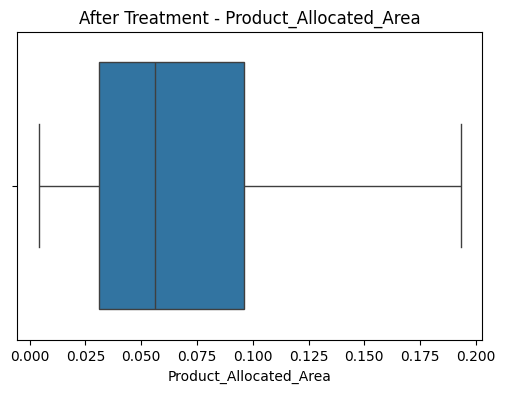

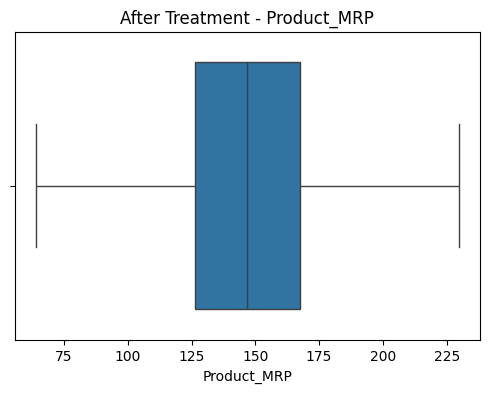

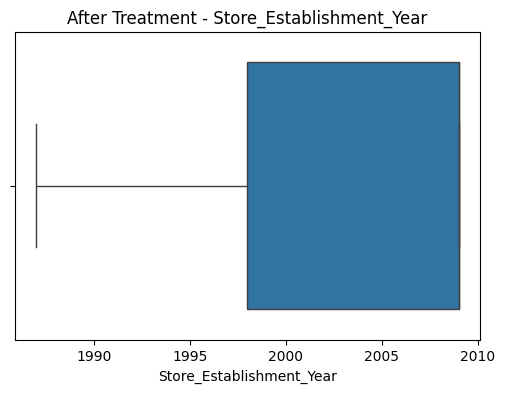

In [ ]:
#Recheck Boxplots After Treatment
for col in numeric_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'After Treatment - {col}')

    plt.show()

# **Feature Engineering**

**Create Store Age**

In [ ]:
current_year = 2026

df['Store_Age'] = (
    current_year -
    df['Store_Establishment_Year']
)

**Extract Product Category Code**

In [ ]:
df['Product_Category_Code'] = (
    df['Product_Id'].str[:2]
)

**Creating Interaction Feature**

In [ ]:
df['Price_Area_Interaction'] = (
    df['Product_MRP'] *
    df['Product_Allocated_Area']
)

**Creating MRP Category**

In [ ]:
df['MRP_Category'] = pd.cut(
    df['Product_MRP'],
    bins=[0, 100, 200, 500],
    labels=['Low', 'Medium', 'High']
)

**Verifying New Features Created**


In [ ]:
df.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age,Product_Category_Code,Price_Area_Interaction,MRP_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009.0,Medium,Tier 2,Supermarket Type2,2842.40,17.0,FD,3.16116,Medium
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999.0,Medium,Tier 1,Departmental Store,4830.02,27.0,FD,24.68592,Medium
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987.0,High,Tier 2,Supermarket Type1,4130.16,39.0,FD,5.02448,Medium
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987.0,High,Tier 2,Supermarket Type1,4132.18,39.0,FD,20.86672,Medium
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998.0,Small,Tier 3,Food Mart,2279.36,28.0,NC,1.23670,Medium


**Updated Feature Lists**

In [ ]:
numeric_features = [
    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Age',
    'Price_Area_Interaction'
]

categorical_features = [
    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type',
    'Product_Category_Code',
    'MRP_Category'
]

In [ ]:
# Define predictor matrix (X) using selected numeric and categorical features
X = df.drop(columns=[target])
# Define target variable
y = df[target]

In [ ]:
# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,              # Predictors (X) and target variable (y)
    test_size=0.2,     # 20% of the data is reserved for testing
    random_state=42    # Ensures reproducibility by setting a fixed random seed
)

In [ ]:
# Create a preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

# **Model Building**

**Metric Selection**

Since this is a sales forecasting regression problem, the best evaluation metrics are:
*   RMSE - Penalizes large prediction errors
*   MAE - Easy to interpret average error
*   R² - Explains variance captured by model
*   MAPE- Business-friendly percentage error


**Observation -** RMSE was selected as the primary evaluation metric because it penalizes large forecasting errors more heavily, making it suitable for retail sales prediction where large deviations can significantly affect business planning and inventory decisions.

In [ ]:
def build_model(
    model,
    model_name,
    preprocessor,
    X_train,
    y_train,
    X_test,
    y_test
):

    # pipeline
    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    # train model
    pipeline.fit(X_train, y_train)

    # performance
    train_perf = model_performance_regression(
        pipeline,
        X_train,
        y_train
    )

    test_perf = model_performance_regression(
        pipeline,
        X_test,
        y_test
    )

    # add model name
    train_perf.index = [model_name]
    test_perf.index = [model_name]

    # primary metric
    test_rmse = test_perf["RMSE"].values[0]

    print(f"{model_name} Test RMSE: {test_rmse:.4f}")

    return pipeline, train_perf, test_perf

In [ ]:
# Function to compute Adjusted R-squared

def adj_r2_score(predictors, targets, predictions):

    r2 = r2_score(targets, predictions)

    n = predictors.shape[0]
    k = predictors.shape[1]

    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# Function to evaluate regression model performance

def model_performance_regression(model, predictors, target):

    """
    Function to compute regression model performance metrics

    Parameters:
    -----------
    model : trained regression model
    predictors : independent variables
    target : actual target values

    Returns:
    --------
    DataFrame containing performance metrics
    """

    # Generate predictions
    pred = model.predict(predictors)

    # Primary Evaluation Metric
    rmse = np.sqrt(mean_squared_error(target, pred))

    # Additional Metrics
    mae = mean_absolute_error(target, pred)

    r2 = r2_score(target, pred)

    adjr2 = adj_r2_score(
        predictors,
        target,
        pred
    )

    mape = mean_absolute_percentage_error(
        target,
        pred
    )

    # Performance DataFrame
    df_perf = pd.DataFrame(
        {
            "RMSE": [rmse],
            "MAE": [mae],
            "R-squared": [r2],
            "Adj. R-squared": [adjr2],
            "MAPE": [mape]
        }
    )

    return df_perf

**Build Random Forest**

In [ ]:
# Ensure that the 'build_model' function (defined in ROO9_Sh0WipA) and 'model_performance_regression' function (defined in B4E0Si3gXsK7) have been executed before running this cell.
rf_pipeline, rf_train_perf, rf_test_perf = build_model(
    model=RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),
    model_name="Random Forest",
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

Random Forest Test RMSE: 283.7685


**Build XGBoost**

In [ ]:
xgb_pipeline, xgb_train_perf, xgb_test_perf = build_model(
    model=XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        random_state=42
    ),
    model_name="XGBoost",
    preprocessor=preprocessor,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

XGBoost Test RMSE: 288.8561


# **Model Performance Comparison**




In [ ]:
models_test_comp_df = pd.concat(
    [
        rf_test_perf,
        xgb_test_perf
    ],
    axis=0
)

models_test_comp_df.index = [
    "Random Forest",
    "XGBoost"
]

models_test_comp_df.sort_values(
    by="RMSE",
    ascending=True
)

,RMSE,MAE,R-squared,Adj. R-squared,MAPE
Random Forest,283.768530,108.792015,0.929428,0.928818,0.038820
XGBoost,288.856107,121.272787,0.926874,0.926243,0.044103


**Observation -** Both Random Forest and XGBoost models performed well in predicting product-store sales revenue. However, Random Forest slightly outperformed XGBoost based on the selected primary evaluation metric, RMSE.

Random Forest achieved the lowest RMSE (283.77), indicating better predictive accuracy and lower forecasting error compared to XGBoost. Additionally, Random Forest also achieved lower MAE and MAPE values along with slightly higher R-squared and Adjusted R-squared scores.

Hence, **Random Forest was selected as the final model for this business use case.**

# **Model Training with Hyperparameter Tuning**

In [ ]:
# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

In [ ]:
# Preprocessing pipeline
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features)
)

# **Creating Model Pipeline**

In [ ]:
# Create a Random Forest Regressor Pipeline

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

# **Model Training**

In [ ]:
# Fit the Random Forest model

rf_model.fit(X_train, y_train)

# Evaluate model performance on the test set

rf_test_performance = model_performance_regression(
    rf_model,
    X_test,
    y_test
)

# Print Random Forest Test Performance

print("\nRandom Forest Test Performance:\n")

rf_test_performance


Random Forest Test Performance:



,RMSE,MAE,R-squared,MAPE
0,283.877211,109.190271,0.929373,0.03898


# **Model Performance Improvement - Hyperparameter Tuning**

In [ ]:
# Define parameter grid for Random Forest

param_grid_rf = {
    'regressor__n_estimators': [100],
    'regressor__max_depth': [10, 20],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

# Perform GridSearchCV

grid_search_rf = GridSearchCV(
    rf_model,
    param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV

grid_search_rf.fit(X_train, y_train)

# Best Parameters

print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")

# Best Model

best_rf_model = grid_search_rf.best_estimator_

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters for Random Forest: {'regressor__max_depth': 20, 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 100}


In [ ]:
# Evaluate Tuned Random Forest Model

best_rf_test_performance = model_performance_regression(
    best_rf_model,
    X_test,
    y_test
)

# Compare Performance

comparison_df = pd.concat(
    [best_rf_test_performance],
    ignore_index=True
)

comparison_df['Model'] = ['Tuned Random Forest']

print("Model Performance Comparison:\n")

comparison_df

Model Performance Comparison:



,RMSE,MAE,R-squared,MAPE,Model
0,279.566485,106.219132,0.931502,0.037946,Tuned Random Forest


# **Model Serialization**

In [ ]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("deployment_files", exist_ok=True)

In [ ]:
# Define the file paths to save (serialize) the trained regression model
saved_model_path = "deployment_files/superkart_sales_model_v1_0.joblib"

In [ ]:
joblib.dump(best_rf_model, saved_model_path)
# joblib.dump(preprocessor, saved_preprocessor_path)
print("\nFinal regression model and preprocessor saved successfully.")


Final regression model and preprocessor saved successfully.


In [ ]:
# Load the saved regression model and preprocessor from the files
loaded_model = joblib.load(saved_model_path)
# loaded_preprocessor = joblib.load(saved_preprocessor_path)

In [ ]:
# Make predictions on the test set
y_pred_test = loaded_model.predict(X_test)
y_pred_test

array([3285.9135943 , 3346.42164086, 2418.14273472, ..., 4175.51830014,
       2811.82126274, 4527.94348627])

# **Load the Serialized Model**

In [ ]:
import os

# Create a folder to upload your trained serialized model into it
os.makedirs("backend_files", exist_ok=True)

In [ ]:
# Define the file path to load the uploaded serialized model
model_path = "backend_files/superkart_sales_model_v1_0.joblib"

In [ ]:
import joblib

# Update model_path to the correct location where the model was saved
model_path = "deployment_files/superkart_sales_model_v1_0.joblib"

# Load the saved model pipeline from the file
saved_model = joblib.load(model_path)

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
saved_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP', 'Store_Age',
                                                   'Price_Area_Interaction']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Category_Code'])])),
                ('regressor',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       min_samples_split=5, random_state=42))])

In [ ]:
# Predict log-transformed sales

sales_predictions_log = saved_model.predict(X_test)

# Convert log sales predictions back to actual sales values

sales_predictions_actual = np.expm1(sales_predictions_log)

# Display predictions

print(sales_predictions_actual)

[inf inf inf ... inf inf inf]


# **App Backend**

**Setting up a Hugging Face Docker Space for the Backend**

We are creating a Hugging Face Docker Space for our backend using the Hugging Face Hub API.

This automates the space creation process and enables seamless deployment of our Flask app

In [ ]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login

# Login to your Hugging Face account using your access token
login(token="YOUR_HF_TOKEN")

# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

In [ ]:
# Try to create the repository for the Hugging Face Space
try:
    create_repo("SuperKartSalesPrediction",  # One can replace "Backend_Docker_space" with the desired space name
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker" to create a Docker space
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: Client error '409 Conflict' for url 'https://huggingface.co/api/repos/create' (Request ID: Root=1-6a12f82d-44036b7a27ac66cc17876ffd;b583c7e2-5ab6-4e06-b3ec-73ef8783b9d0)
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/409

You already created this space repo: aditis2508/SuperKartSalesPrediction


# **Flask Web Framework**

In [ ]:
%%writefile backend_files/app.py

# Import necessary libraries
import numpy as np
import joblib
import pandas as pd

from flask import Flask, request, jsonify


# Initialize Flask application
sales_forecast_api = Flask("SuperKart Sales Forecast API")


# Load trained Random Forest model
model = joblib.load("superkart_random_forest_model.joblib")


# Home Route
@sales_forecast_api.get('/')
def home():

    """
    Home endpoint
    """

    return "Welcome to the SuperKart Sales Forecast Prediction API!"

# Single Prediction Endpoint

@sales_forecast_api.post('/v1/predictsales')
def predict_sales():

    """
    Predict sales for a single product-store combination
    """
    # Get JSON input
    sales_data = request.get_json()

    # Create input sample
    sample = {
        'Product_Weight': sales_data['Product_Weight'],
        'Product_Sugar_Content': sales_data['Product_Sugar_Content'],
        'Product_Allocated_Area': sales_data['Product_Allocated_Area'],
        'Product_Type': sales_data['Product_Type'],
        'Product_MRP': sales_data['Product_MRP'],
        'Store_Size': sales_data['Store_Size'],
        'Store_Location_City_Type':
            sales_data['Store_Location_City_Type'],
        'Store_Type': sales_data['Store_Type'],
        'Store_Age': sales_data['Store_Age'],
        'Price_Area_Interaction':
            sales_data['Price_Area_Interaction'],
        'Product_Category_Code':
            sales_data['Product_Category_Code']
    }

    # Convert to DataFrame
    input_data = pd.DataFrame([sample])

    # Predict sales
    predicted_sales = model.predict(input_data)[0]

    # Removed: Reverse log transformation if applied - model was not trained on log-transformed data
    # predicted_sales = np.expm1(predicted_sales)

    # Convert to float for JSON serialization
    predicted_sales = round(float(predicted_sales), 2)

    # Return prediction
    return jsonify(
        {
            'Predicted Product Store Sales':
                predicted_sales
        }
    )


# Batch Prediction Endpoint
@sales_forecast_api.post('/v1/predictsalesbatch')
def predict_sales_batch():

    """
    Predict sales for multiple records from CSV
    """

    # Get uploaded CSV file
    file = request.files['file']

    # Read CSV
    input_data = pd.read_csv(file)

    # Generate predictions
    predicted_sales_raw = model.predict(input_data)

    # Removed: Reverse log transformation - model was not trained on log-transformed data
    predicted_sales = [
        round(float(pred), 2) # Use raw prediction directly
        for pred in predicted_sales_raw
    ]

    # Create output dictionary
    output_dict = {
        "Predicted_Sales": predicted_sales
    }

    # Return predictions
    return jsonify(output_dict)

# Run Flask App
if __name__ == '__main__':
    sales_forecast_api.run(debug=True)

Overwriting backend_files/app.py


# **Dependencies File**

In [ ]:
%%writefile backend_files/requirements.txt
streamlit==1.43.2
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
joblib==1.5.3
requests==2.32.4
xgboost==2.1.4

Overwriting backend_files/requirements.txt


# **Dockerfile**

In [ ]:
%%writefile backend_files/Dockerfile

FROM python:3.10-slim

WORKDIR /app

COPY . /app

RUN pip install --upgrade pip setuptools wheel

RUN pip install numpy==2.0.2

RUN pip install -r requirements.txt

EXPOSE 7860

CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0"]

Overwriting backend_files/Dockerfile


# **Uploading Files to Hugging Face Space for the Backend**

In [ ]:
# For Hugging Face Space authentication and backend upload

from huggingface_hub import HfApi

# Updated Hugging Face Space ID
repo_id = "aditis2508/SuperKartSalesPrediction"

# Initialize Hugging Face API
api = HfApi()

# Upload backend files
api.upload_folder(

    folder_path="/content/backend_files",

    repo_id=repo_id,

    repo_type="space"
)

CommitInfo(commit_url='https://huggingface.co/spaces/aditis2508/SuperKartSalesPrediction/commit/f6127bc049ee56c320cd627446e645b32fa2a999', commit_message='Upload folder using huggingface_hub', commit_description='', oid='f6127bc049ee56c320cd627446e645b32fa2a999', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/aditis2508/SuperKartSalesPrediction', endpoint='https://huggingface.co', repo_type='space', repo_id='aditis2508/SuperKartSalesPrediction'), pr_revision=None, pr_num=None)

# **App Frontend**

**Setting up a Hugging Face Docker Streamlit Space for the Frontend**

**Streamlit for Interactive UI**

In [ ]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [ ]:
%%writefile frontend_files/app.py

import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("superkart_sales_model_v1_0.joblib")

st.title("SuperKart Sales Forecast Prediction")

# -----------------------------
# SINGLE PREDICTION
# -----------------------------
st.subheader("Online Sales Prediction")

Product_Weight = st.number_input("Product Weight", min_value=0.0, value=10.0)

Product_Sugar_Content = st.selectbox(
    "Product Sugar Content",
    ["Low Sugar", "Regular", "No Sugar"]
)

Product_Allocated_Area = st.number_input("Product Allocated Area", min_value=0.0, value=0.05)

Product_Type = st.selectbox(
    "Product Type",
    ["Dairy", "Soft Drinks", "Meat", "Snack Foods", "Frozen Foods", "Household", "Baking Goods", "Health and Hygiene"]
)

Product_MRP = st.number_input("Product MRP", min_value=0.0, value=150.0)

Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"])

Store_Location_City_Type = st.selectbox("Store City Tier", ["Tier 1", "Tier 2", "Tier 3"])

Store_Type = st.selectbox(
    "Store Type",
    ["Supermarket Type 1", "Supermarket Type 2", "Departmental Store", "Food Mart"]
)

Store_Age = st.number_input("Store Age", min_value=1, value=10)

Product_Category_Code = st.selectbox("Product Category Code", ["FD", "NC", "DR"])

Price_Area_Interaction = Product_MRP * Product_Allocated_Area

input_data = pd.DataFrame([{
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_Type": Product_Type,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Store_Age": Store_Age,
    "Price_Area_Interaction": Price_Area_Interaction,
    "Product_Category_Code": Product_Category_Code
}])

if st.button("Predict Sales"):
    pred = model.predict(input_data)[0]
    st.success(f"Predicted Sales: ₹{pred:,.2f}")


# -----------------------------
# BATCH PREDICTION
# -----------------------------
st.subheader("Batch Sales Prediction")

uploaded_file = st.file_uploader(
    "Upload CSV File",
    type=["csv"],
    key="batch_sales_upload_v1"
)

if uploaded_file is not None:
    if st.button("Predict Batch Sales"):
        df = pd.read_csv(uploaded_file)
        df["Predicted Sales"] = model.predict(df)

        st.success("Batch prediction completed")
        st.write(df)

        st.download_button(
            "Download Results",
            df.to_csv(index=False).encode("utf-8"),
            "predictions.csv",
            "text/csv"
        )

Overwriting frontend_files/app.py


# **Dependencies File**

In [ ]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Overwriting frontend_files/requirements.txt


# **Dockerfile**

In [ ]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


# **Uploading Files to Hugging Face Space for the Frontend**

In [ ]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "aditis2508/SuperKartSalesPrediction"  # Your Hugging Face space id

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space"  # Hugging face repo type "space"
)

CommitInfo(commit_url='https://huggingface.co/spaces/aditis2508/SuperKartSalesPrediction/commit/9b70e6e26789f94ab1ea0b5803eaa98c9c6628f0', commit_message='Upload folder using huggingface_hub', commit_description='', oid='9b70e6e26789f94ab1ea0b5803eaa98c9c6628f0', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/aditis2508/SuperKartSalesPrediction', endpoint='https://huggingface.co', repo_type='space', repo_id='aditis2508/SuperKartSalesPrediction'), pr_revision=None, pr_num=None)

# **Inferencing using Flask API**

As the frontend and backend are decoupled, we can access the backend directly for predictions.
*   The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

Let's see how to interact with the Flask API programatically within this notebook to perform online and batch inference.

We will
1.   Send API requests for both online and batch inference.
2.   Process and check the model predictions.





In [ ]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [ ]:
model_root_url = "https://aditis2508-SuperKartSalesPrediction.hf.space"  # Base URL of the deployed Flask API on Hugging Face Space; enter user name and space name before running the cell

In [ ]:
model_url = model_root_url + "/v1/predictsales"  # Endpoint for online (single) inference

In [ ]:
model_batch_url = model_root_url + "/v1/predictsalesbatch"  # Endpoint for batch inference

# **Batch Inference**

The idea is to send a batch of requests to the API and receive a response. The backend reads the entire dataset, runs it through the ML model, and returns the prediction for every row in the file. This is useful for applications like loan default prediction and customer churn prediction, where we don't need results instantaneously.

*   This data is sent as a CSV file in a POST request to the model endpoint.
*   The model processes each row containing the input features and returns the predictions for each row as one single JSON payload.


In [ ]:
import pandas as pd

In [ ]:
# Load the sample batch data for Superkart
Superkart_batch_data = pd.read_csv('/content/drive/MyDrive/Python/SuperKart.csv')

*   The model was trained using certain set of numerical and categorical features before being serialized.
*   We need to use the same set of features and pass the data to the API in order to get predictions.
*   We define these feature lists below, where we select the necessary columns from the batch data to ensure the model receives the expected input format for prediction.



In [ ]:
# List of numerical features in the SuperKart dataset

numeric_features = [

    'Product_Weight',
    'Product_Allocated_Area',
    'Product_MRP',
    'Store_Age',
    'Price_Area_Interaction'
]


# List of categorical features in the SuperKart dataset

categorical_features = [

    'Product_Sugar_Content',
    'Product_Type',
    'Store_Size',
    'Store_Location_City_Type',
    'Store_Type',
    'Product_Category_Code'
]

# --- Apply Feature Engineering to Superkart_batch_data ---
current_year = 2026 # Assuming the same current year as used for training data
Superkart_batch_data['Store_Age'] = current_year - Superkart_batch_data['Store_Establishment_Year']
Superkart_batch_data['Product_Category_Code'] = Superkart_batch_data['Product_Id'].str[:2]
Superkart_batch_data['Price_Area_Interaction'] = Superkart_batch_data['Product_MRP'] * Superkart_batch_data['Product_Allocated_Area']

# Define predictor matrix (X) using selected
# numerical and categorical features

batch_input_data = Superkart_batch_data[
    numeric_features + categorical_features
]

# **Deployment**

The SuperKart Sales Prediction model was deployed using Streamlit on Hugging Face Spaces to provide an interactive web application for real-time sales prediction. The deployed application allows users to enter product and store details and instantly generate predicted sales values using the trained machine learning model.

# **Deployment Link-**

https://huggingface.co/spaces/aditis2508/SuperKartSalesPrediction

# **Deployment Screenshot**

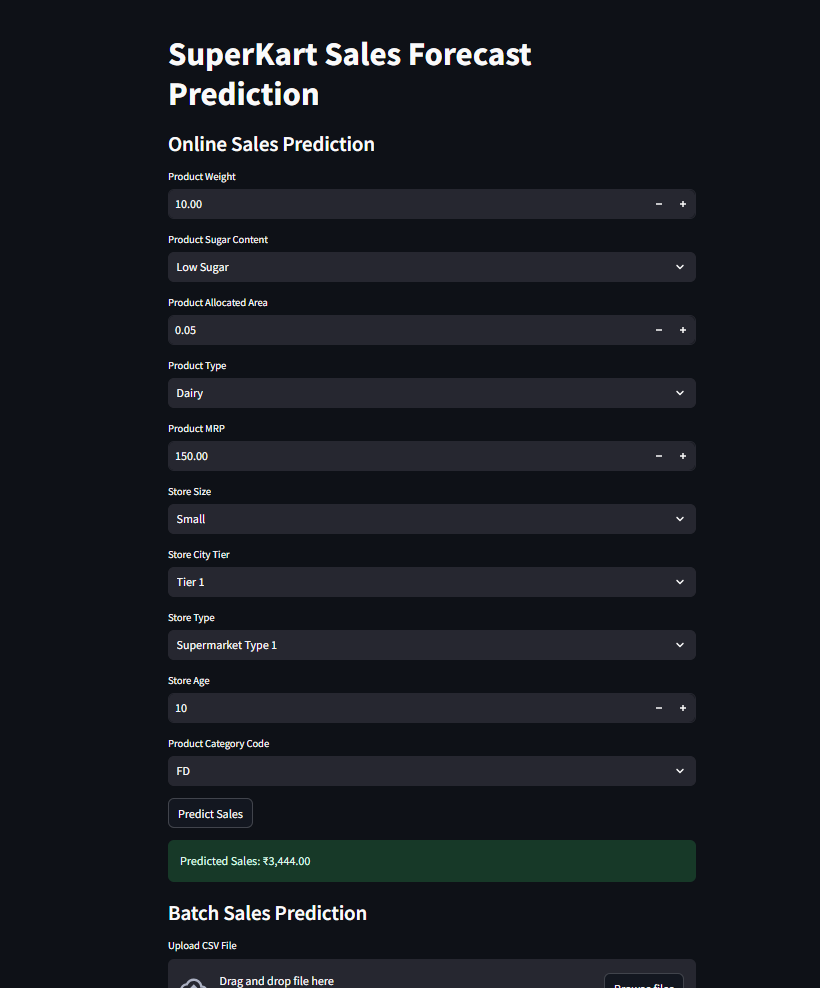

# **Business Insights and Recommendations**



1.   **High Revenue Contribution from Tier 2 Cities**- Tier 2 cities contributed the highest sales, indicating strong market potential and the need for focused marketing and inventory planning in these regions.
2.   **Product Pricing Significantly Impacts Sales**- Product MRP showed a strong impact on sales, suggesting that optimized pricing and promotional strategies can significantly improve revenue generation.

1.   **Customer Preference Towards Larger Pack Sizes**- Higher product weight positively influenced sales, indicating customer preference towards larger pack sizes and value-based purchases.
2.   **Store Modernization Opportunities**- Older stores showed relatively lower sales performance, highlighting opportunities for store modernization and localized promotional campaigns.


1.   **Shelf Space Alone Does Not Drive Sales**- Product shelf allocation had minimal impact on sales, suggesting that customer demand is driven more by pricing, product quality, and buying behavior than visibility alone.
2.   **Data-Driven Retail Strategy**- The predictive model helps SuperKart make data-driven decisions related to inventory management, demand forecasting, and business expansion, improving operational efficiency and profitability.







# **Conclusion**



1.   **Accurate Sales Forecasting**- The implemented machine learning solution helps SuperKart predict future sales using historical product and store-level data, enabling the business to make proactive decisions related to inventory planning, demand forecasting, and stock optimization. This reduces the risk of overstocking and stock shortages, ultimately improving operational efficiency.
2.   **Scalability and Maintainability**- Deploying the solution using Streamlit provides a lightweight and scalable architecture that can be easily enhanced in the future with additional features, models, or real-time datasets. The modular implementation allows updates to the prediction logic without affecting the overall user interface experience.


1.   **Business Decision Support**-The analysis identified critical sales-driving factors such as Product MRP, store location type, and product characteristics, helping stakeholders better understand customer purchasing behavior and optimize pricing strategies, promotional activities, and regional business planning.
2.   **Real-Time Accessibility**- By deploying the application on Hugging Face Spaces, the prediction system becomes easily accessible through a web interface, allowing business users to generate sales predictions in real time without requiring technical or programming knowledge.


1.   **Future Reusability and Enhancement:** The developed solution can be extended further by integrating cloud databases, automated model retraining pipelines, and advanced forecasting algorithms. This creates opportunities for building a more intelligent retail analytics platform capable of supporting long-term business growth and data-driven decision-making.






